In [29]:
import pandas as pd
import numpy as np 
import seaborn as sns

In [30]:
customer_data = pd.read_csv("Ecommerce_Customers.csv")
customer_data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [31]:
pd.DataFrame({
    "Matrix" : ["columns", "rows", "null_values", "duplicated_values"],
    "count" : [customer_data.shape[0], customer_data.shape[1], customer_data.isnull().sum().sum(), customer_data.duplicated().sum()],
})

,Matrix,count
0,columns,500
1,rows,8
2,null_values,0
3,duplicated_values,0


In [32]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


##### 5 Numerical Values and 3 categorical Values --> Linear Regression

In [33]:
customer_data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### EDA

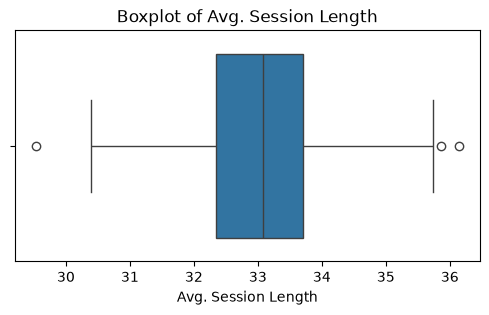

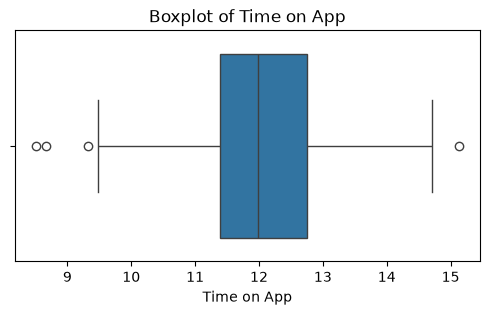

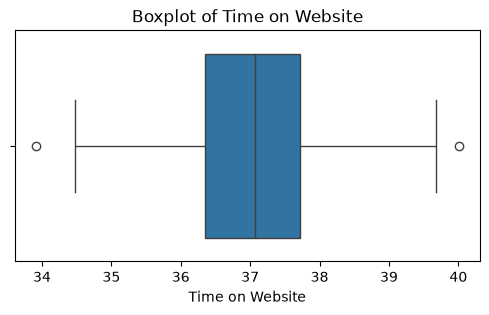

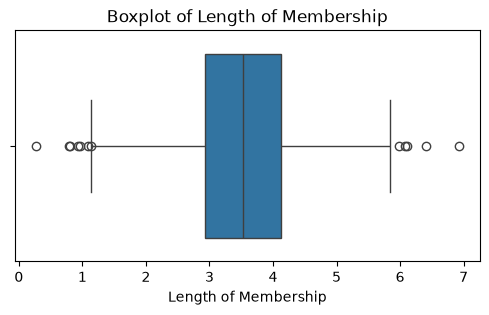

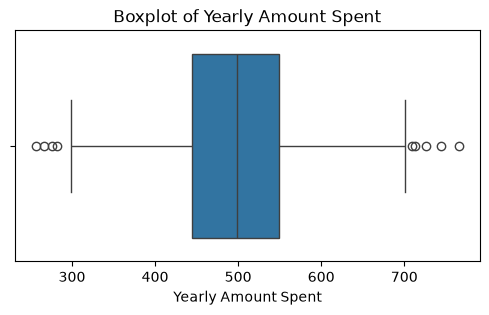

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = customer_data.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=customer_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

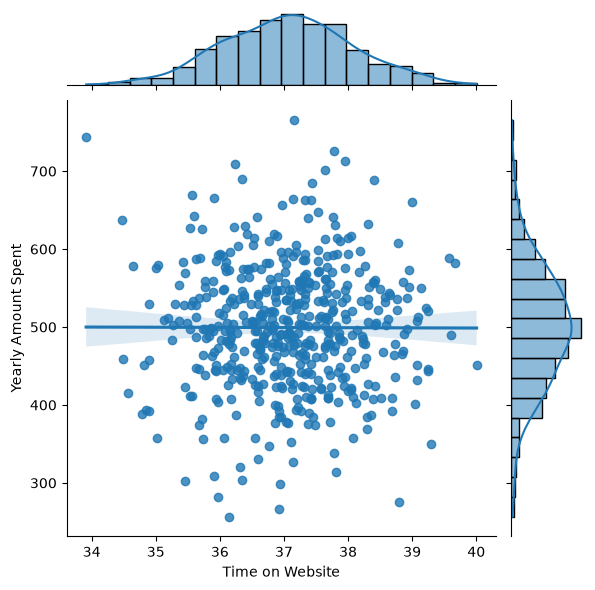

In [35]:
sns.jointplot(customer_data, x = 'Time on Website', y = 'Yearly Amount Spent', kind='reg') 
# sns.jointplot(customer_data, x = 'Time on Website', y = 'Yearly Amount Spent', kind='scatter', alpha=0.5) 

# show no corelation -> x not much depend on y

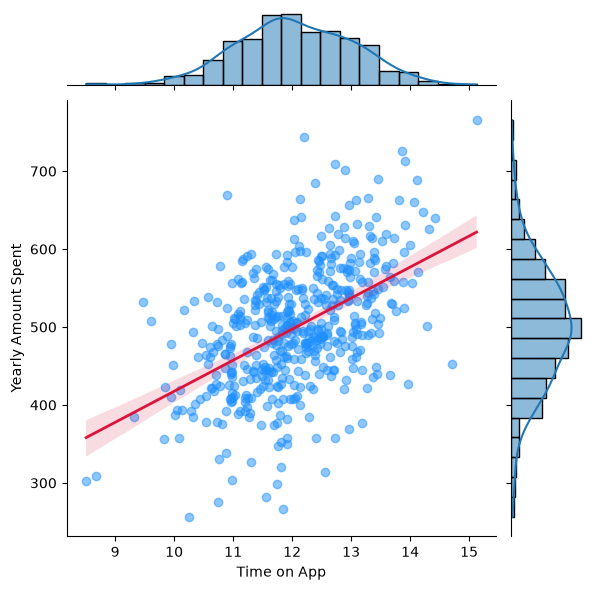

In [36]:
sns.jointplot(
    data=customer_data,
    x="Time on App",
    y="Yearly Amount Spent",
    kind="reg",
    scatter_kws={
        "alpha": 0.5,
        "color": "dodgerblue"
    },
    line_kws={
        "color": "crimson",
        "linewidth": 2
    }
)

# the people spending money == more time you spend on app --> shows a high corelation

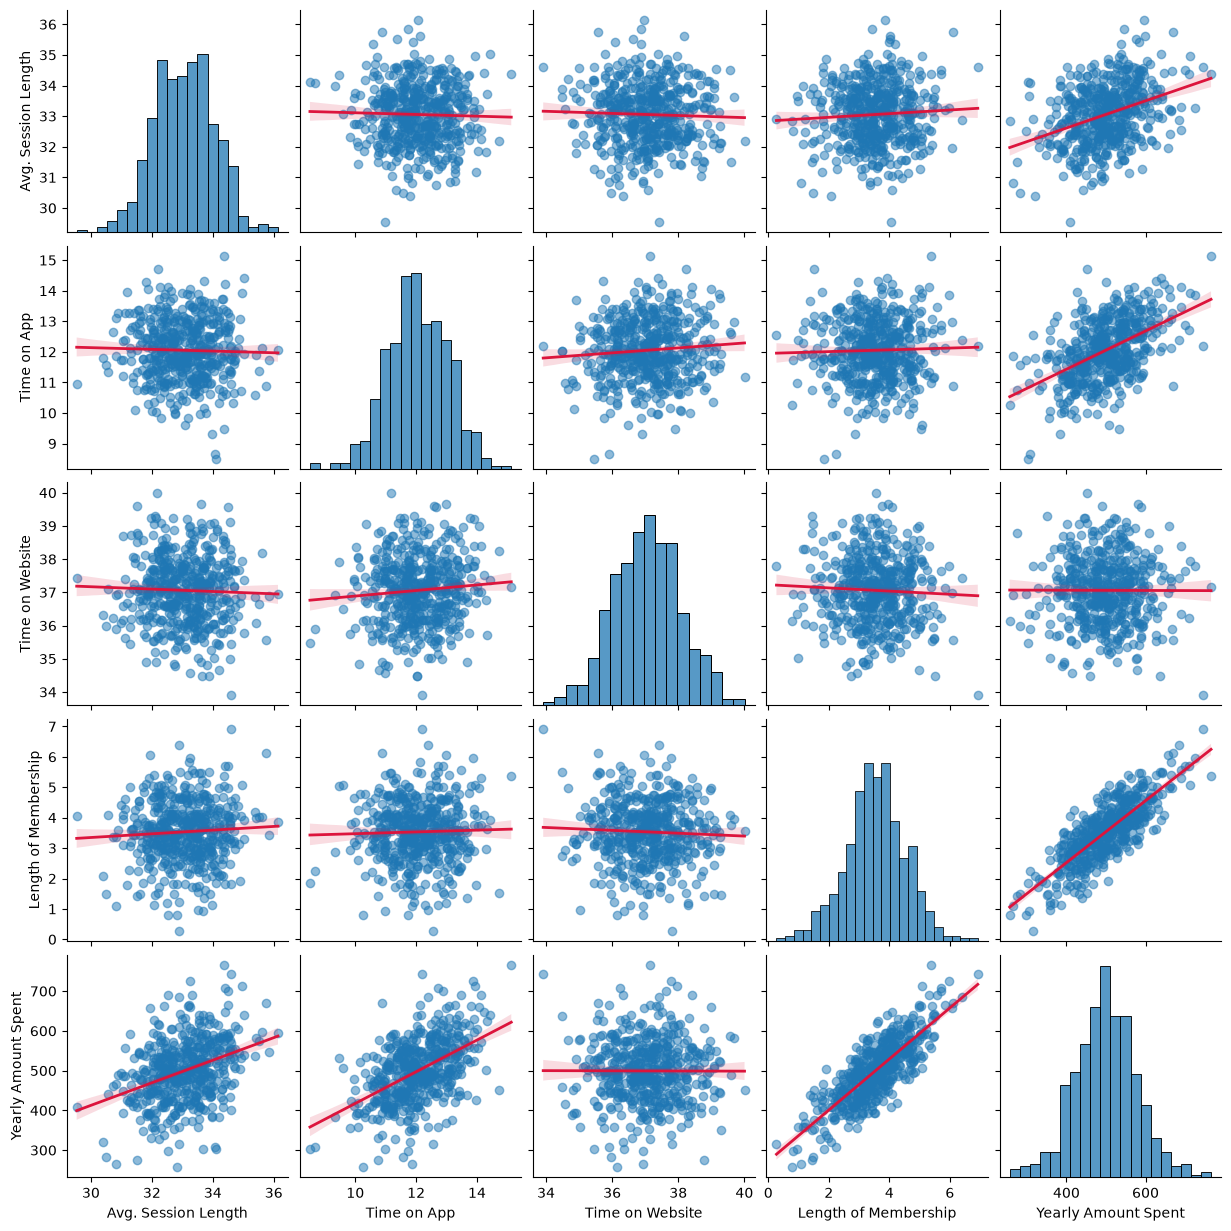

In [37]:

sns.pairplot(customer_data, 
    kind='reg',
    plot_kws={
        "scatter_kws": {"alpha": 0.5},
        "line_kws": {
        "color": "crimson",
        "linewidth": 2}
    }
) 

# Conclusion -> Yearly spends depend on feature like Avg. session length, Time on App and Length of membership

In [38]:
from sklearn.model_selection import train_test_split

x = customer_data[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customer_data[['Yearly Amount Spent']]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

X_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
5,33.871038,12.026925,34.476878,5.493507
116,33.925795,12.011022,36.701052,2.753424
45,34.555768,12.170525,39.131097,3.663105
16,32.125387,11.733862,34.894093,3.136133
462,33.503810,11.233415,37.211153,2.320550
...,...,...,...,...
106,32.291756,12.190474,36.152462,3.781823
270,34.006489,12.956277,38.655095,3.275734
348,31.812483,10.886921,34.897828,3.128639
435,32.259973,14.132893,37.023479,3.762070


In [39]:
# training the Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr.coef_ # cofficient of linear Regression

array([[25.72425621, 38.59713548,  0.45914788, 61.67473243]])

In [40]:
cdf = pd.DataFrame(lr.coef_.T, x.columns, columns=['Coef'])
cdf

,Coef
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


In [41]:
# Predictions

predictions = lr.predict(X_test)
predictions

array([[403.66993069],
       [542.57756289],
       [427.06591658],
       [502.02460425],
       [410.12143559],
       [569.93442508],
       [531.93431341],
       [506.29650969],
       [408.71870658],
       [473.97737105],
       [441.46912726],
       [425.33703059],
       [425.1297229 ],
       [527.61676714],
       [431.45684016],
       [424.0769184 ],
       [575.76543296],
       [484.89856554],
       [458.35936863],
       [481.96502182],
       [502.32441491],
       [513.63783554],
       [507.58877002],
       [646.57464283],
       [450.24372141],
       [496.27043415],
       [556.40457807],
       [554.95630839],
       [399.64237199],
       [325.84623136],
       [532.89783259],
       [478.12238702],
       [501.05701845],
       [305.97335848],
       [505.77244448],
       [483.79591969],
       [518.8331528 ],
       [438.18241857],
       [456.71094234],
       [471.04609461],
       [494.44008972],
       [445.31155755],
       [508.78802753],
       [501

Text(0.5, 1.0, 'Evaluation of our LM model')

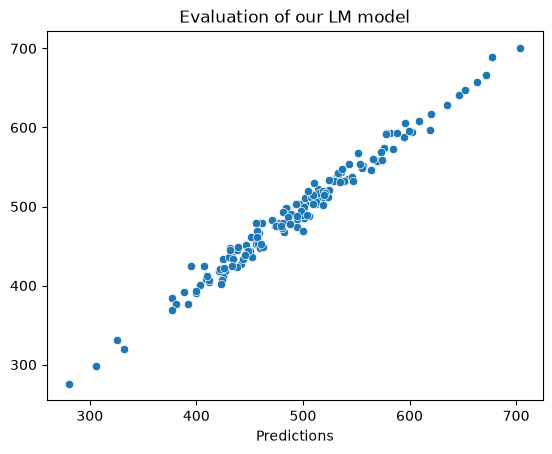

In [42]:
sns.scatterplot(x = predictions.flatten(),y = y_test.values.flatten())
plt.xlabel("Predictions")
plt.title("Evaluation of our LM model")

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Mean Absolute Errors: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Errors: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test,predictions)))

Mean Absolute Errors:  8.426091641432116
Mean Squared Errors:  103.91554136503333
RMSE:  10.193897260863155


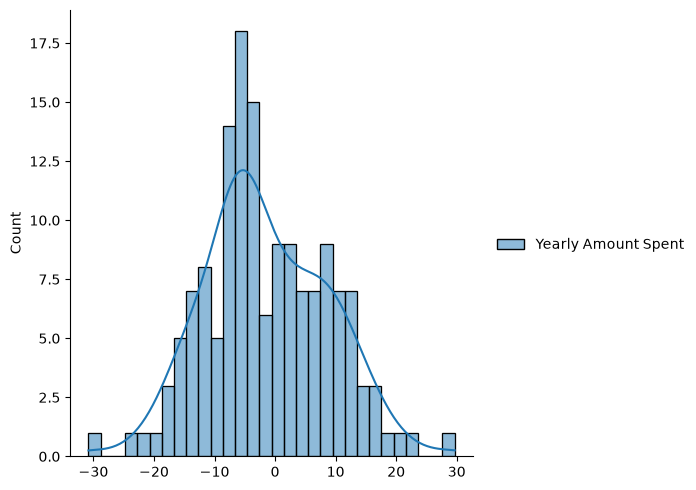

In [44]:
# Residuals/error
residuals = y_test - predictions

sns.displot(residuals, bins=30, kde = True)

C:\Users\bhave\AppData\Local\Temp\ipykernel_20964\609577255.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  stats.probplot(residuals, dist='norm', plot=pylab)
c:\Users\bhave\OneDrive\Desktop\ML Projects\Linear Regression Project\venv\Lib\site-packages\scipy\stats\_stats_py.py:10940: RuntimeWarning: invalid value encountered in divide
  slope = ssxym / ssxm


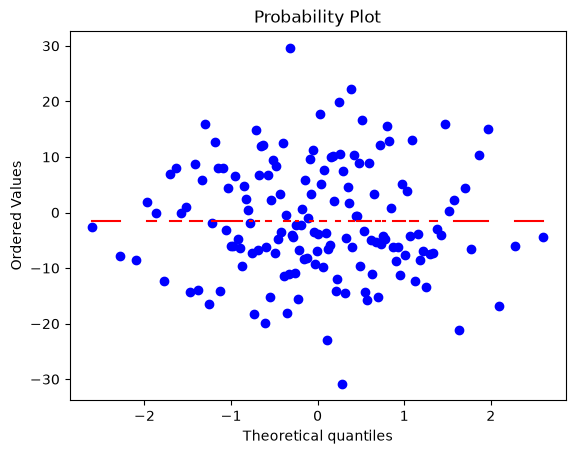

In [45]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist='norm', plot=pylab)
pylab.show()